# Level 1 — Task 1: Data Preprocessing for Machine Learning

### Objective

The goal of this notebook is to prepare the customer churn dataset for machine learning by inspecting the dataset, identifying data quality issues, encoding categorical variables, scaling numerical features, and splitting the data into training and testing sets.

### Workflow

1. Load raw dataset
2. Inspect dataset structure and data quality
3. Encode categorical features
4. Drop collinear and redundant features
5. Scale numerical features
6. Split into training and test sets
7. Save processed datasets

In [155]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[2] # Go up two directories

# Add project root to Python's module search path so notebook can import from src/
if str(ROOT) not in sys.path: # Prevent duplicate path entries
    sys.path.append(str(ROOT)) # Add project root

DATA_DIR = ROOT / "data"

In [156]:
import pandas as pd

# Load data
df = pd.read_csv(DATA_DIR / 'raw/churn/churn-bigml-80.csv')

# Get info, shape, and check missing values
print(f"Shape of dataframe: {df.shape}")
print ("=" * 50)

df.info()
print ("=" * 50)

df.isnull().sum()

Shape of dataframe: (2666, 20)
<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge  

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

The dataset is mostly numerical, with a few categorical columns and one boolean target column (`Churn`). Since machine learning models require numerical input, the categorical columns will need to be handled before modeling.

In [157]:
# Convert text-like columns to pandas' newer string dtype
df = df.convert_dtypes()

# Select string columns
categorical_columns = df.select_dtypes(include="string").columns
print(f"Cardinality in 'State' column: {df['State'].nunique()}")

df[categorical_columns]

Cardinality in 'State' column: 51


,State,International plan,Voice mail plan
0,KS,No,Yes
1,OH,No,Yes
2,NJ,No,No
3,OH,Yes,No
4,OK,Yes,No
...,...,...,...
2661,SC,No,No
2662,AZ,No,Yes
2663,WV,No,No
2664,RI,No,No


### Handling the `State` Column

The `State` column is a categorical feature containing 51 unique state values. In order for machine learning models to use this column, the state names would need to be converted into numerical features through encoding.

One possible approach would be one-hot encoding, which would create a separate column for each state. However, this would add many additional columns to the dataset and make the preprocessing workflow more complicated.

Since this project focuses on building a clean and understandable preprocessing pipeline, the `State` column will be removed. This helps keep the dataset simpler while avoiding the creation of many low-information features (high dimensionality).

In [158]:
# Remove the high-cardinality State column
df = df.drop("State", axis=1)

df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.7,1,False
1,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False
2,137,415,No,No,0,243.4,114,41.38,121.2,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,Yes,No,0,299.4,71,50.9,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


Keep `Area code` as it has low cardinality and still could provide useful insight.

In [159]:
# Identify unique values in 'Area code' to check cardinality
df['Area code'].unique()

<IntegerArray>
[415, 408, 510]
Length: 3, dtype: Int64

### Encoding Binary Categorical Features

The `International plan` and `Voice mail plan` columns contain two possible values: `Yes` and `No`. Since machine learning models require numerical input, these values are converted into binary numeric features.

This keeps the transformation simple, readable, and appropriate for binary categorical variables.

Iterating through each categorical (string) column confirmed that the entries are clean and consistent. Since the columns only contain the values `Yes` and `No`, they can be safely encoded into numerical values for machine learning.

We use explicit/manual preprocessing as the transformation is simple enough to explain clearly. Some machine learning algorithms may interpret higher values with increased magnitude/weight. In this case, encoding Yes to 1 represents presence/true, No to 0 represents absence/false.

In [160]:
# Select string columns
categorical_columns = df.select_dtypes(include="string").columns

# Display the unique values in each categorical column
for column in categorical_columns: # iterate over categorical columns
    print(column) # column name
    print(df[column].unique()) # unique values
    print("=" * 30)

International plan
<StringArray>
['No', 'Yes']
Length: 2, dtype: string
Voice mail plan
<StringArray>
['Yes', 'No']
Length: 2, dtype: string


In [161]:
# Select columns that need to be encoded
binary_columns = ["International plan", "Voice mail plan"]

# Encode binary Yes/No columns as numeric values.
# Yes = 1 means customer has plan.
# No = 0 means customer does not have plan.
for column in binary_columns: # iterate and encode each column
    df[column] = df[column].map({
        "Yes": 1,
        "No": 0
    })

df[binary_columns].head()

,International plan,Voice mail plan
0,0,1
1,0,1
2,0,0
3,1,0
4,1,0


In [162]:
# Check dtypes
df[binary_columns].dtypes

International plan    int64
Voice mail plan       int64
dtype: object

### Handling Multicollinearity

Some columns are derived from others, meaning one is just a formula applied to another (in this case, charge = minutes * abitrary rate). Keeping both gives the model no extra information while adding noise.

If two columns sound like cause/effect or input/output, one may be derived from the other. Dividing one column by the other collinear column will yield the same quotient in every row. In this case, choose any row and divide `Total day minutes` by `Total day charge`, the quotient will always be approximately 0.17.

In essence, if one column can be derived from another, meaning if one feature can be derived from another feature, that means the dataset has redudant columns. One way to think of it is to connect collinearity to linear dependency, where a column in a matrix is redundant/provides no extra information (they aren't the same concept).

Running the code df[collinear_cols].corr() will show a value of ~1.0 between the corresponding column pairs.

In [163]:
collinear_cols = [
    'Total day minutes', 'Total day charge',
    'Total eve minutes', 'Total eve charge',
    'Total night minutes', 'Total night charge',
    'Total intl minutes', 'Total intl charge'
]

df[collinear_cols].corr()

,Total day minutes,Total day charge,Total eve minutes,Total eve charge,Total night minutes,Total night charge,Total intl minutes,Total intl charge
Total day minutes,1.000000,1.000000,0.003999,0.003992,0.013491,0.013464,-0.011042,-0.010934
Total day charge,1.000000,1.000000,0.004008,0.004002,0.013495,0.013468,-0.011046,-0.010938
Total eve minutes,0.003999,0.004008,1.000000,1.000000,-0.013414,-0.013450,-0.006915,-0.006947
Total eve charge,0.003992,0.004002,1.000000,1.000000,-0.013428,-0.013464,-0.006923,-0.006955
Total night minutes,0.013491,0.013495,-0.013414,-0.013428,1.000000,0.999999,-0.008607,-0.008510
Total night charge,0.013464,0.013468,-0.013450,-0.013464,0.999999,1.000000,-0.008615,-0.008517
Total intl minutes,-0.011042,-0.011046,-0.006915,-0.006923,-0.008607,-0.008615,1.000000,0.999993
Total intl charge,-0.010934,-0.010938,-0.006947,-0.006955,-0.008510,-0.008517,0.999993,1.000000


A correlation coefficient close to 1.0 indicates that two features move almost perfectly together. This does not always imply redundancy, but in this case the charge columns are directly calculated from the corresponding minute columns, confirming that they contain nearly identical information.

AttributeError: QuadMesh.set() got an unexpected keyword argument 'smap'

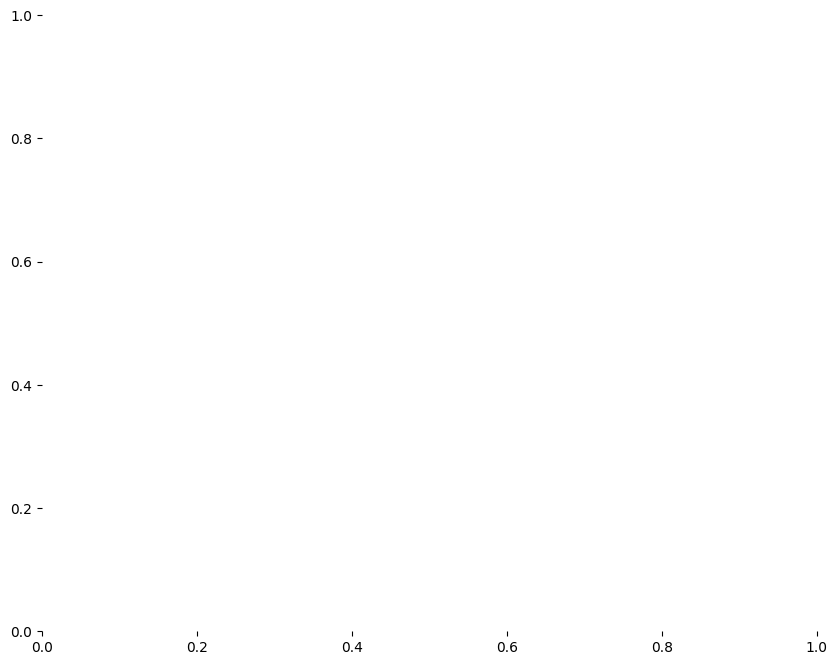

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize correlations between potentially redundant features
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[collinear_cols].corr(),
    annot=True,
    fmt=".2f", # formatting
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Potentially Redundant Features")
plt.show()

### Removing Redundant Features

The charge-related columns are directly derived from their corresponding minute columns. Since the charge values can be calculated from the minute values, they provide no additional information to the model.

Keeping both the minute and charge columns would introduce redundant features (multicollinearity), increasing noise/redundancy in the dataset. To simplify the dataset while preserving the same information, the charge columns will be removed.

In [ ]:
# Remove charge columns because they are derived from their corresponding minute columns
redundant_columns = [
    "Total day charge",
    "Total eve charge",
    "Total night charge",
    "Total intl charge"
]

df = df.drop(columns=redundant_columns)

df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,415,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,415,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,408,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,415,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


### Feature Scaling

Not all machine learning models are affected by feature scaling in the same magnitude. Decision Trees, for example, evaluate features independently by creating splits such as "Is Total Day Minutes > 250?". Since the algorithm doesn't take into account of other features when making that decision. Decision Trees are generally scale-invariant, the numerical scale of a feature usually has little impact on the model's performance.

Distance-based algorithms such as K-Nearest Neighbors (KNN) are much more susceptible to feature scaling. KKN determines which data points are most similar by measuring the distance between them across all features. If one feature has much larger numerical values than another, it can dominate the distance calculation even if it's not significant for predicting the target variable. 

For example, a difference of 50 in `Total Day Minutes` may overshadow a difference of 2 in `Customer Service Calls`, which causes the algorithm to place more emphasis on the larger-scale feature. Larger numerical values should not automatically be marked feature important.

Scaling helps place numerical features on a more comparable range so that large values do not automatically dominate smaller ones. This allows the model to learn patterns based on the information contained in each feature rather than being influenced by the size of the numbers alone.

In [ ]:
# Identify numerical columns and their ranges
num_columns_range = df.select_dtypes(include=["int64", "float64"]).agg(['min', 'max'])

num_columns_range

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls
min,1,408,0,0,0,0.0,0,0.0,0,43.7,33,0.0,0,0
max,243,510,1,1,50,350.8,160,363.7,170,395.0,166,20.0,20,9


In [ ]:
# Select columns excluded from scaling
excluded_columns = ['International plan', 'Voice mail plan', 'Area code']

# Select columns that need to be scaled
columns_to_scale = (
    df.select_dtypes(include=["int64", "float64"])
    .columns # get column names
    .difference(excluded_columns) # remove excluded columns
    .tolist() # convert to list
)

### Preventing Data Leakage

The dataset is split into training and test sets before feature scaling. This prevents data leakage, which occurs when information from the test set influences the training process.

Standardization calculates the mean and standard deviation of each feature. If scaling is performed before the train-test split, these statistics would be calculated using both training and test data. The scaling parameters would be influenced by the test set, meaning the model indirectly gains information about unseen data during the preprocessing pipeline.

To avoid this, the data will first be split into training and test sets. The scalar is then only fitted on the training data and applied to both datasets using the same scaling parameters. This ensures the test set remains unseen during training, providing a more realistic evaluation of model performance.

In [ ]:
from sklearn.model_selection import train_test_split

# Split data
X = df.drop("Churn", axis=1) # features
y = df["Churn"] # target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # ensure equal class distribution in train/test sets
)

# Check class distribution
y.value_counts(normalize=True)

Churn
False    0.854464
True     0.145536
Name: proportion, dtype: Float64

The target variable is imbalanced, with approximately 85% of customers not churning and 15% of customers churning. Using `stratify=y` ensures that the train and test sets maintain approximately the same class distribution as the original dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data
scaler.fit(X_train[columns_to_scale]) # Scaler learns training mean and std

# Transform data using scaling parameters from training data only
X_train[columns_to_scale] = scaler.transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

Following code checks whether the split was performed correct and if the class distribution is approximate 85% true and 15% false.

In [ ]:
# train and test should add up to original dataset shape
# assert statement, if false raise error with message
assert X_train.shape[0] + X_test.shape[0] == df.shape[0], "X split failed" 
assert y_train.shape[0] + y_test.shape[0] == df.shape[0], "y split failed"
print("Split successful")

print('=' * 30)

# iterate over list of label-object tuples
for label, obj in [("X_train", X_train), ("X_test", X_test),
                   ("y_train", y_train), ("y_test", y_test)]:
    print(f"{label} shape: {obj.shape}")

Split successful
X_train shape: (2132, 14)
X_test shape: (534, 14)
y_train shape: (2132,)
y_test shape: (534,)


In [ ]:
# Check class distribution
y_train.value_counts(normalize=True) # normalize to get proportions instead of counts

Churn
False    0.854597
True     0.145403
Name: proportion, dtype: Float64

In [ ]:
y_test.value_counts(normalize=True)

Churn
False    0.853933
True     0.146067
Name: proportion, dtype: Float64

### Feature Scaling Methods
Normalization rescales values to a fixed range (typically 0–1). Also known as min-max scaling, it transforms the data so that the minimum value becomes 0 and the maximum value becomes 1, with all other values scaled proportionally between them.

Standardization centers values around the average and measures how far above or below each entry is from the average. Neither methods are superior to the other, and choices depends on the machine learning algorithms being used and the characteristics of the dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scalar = StandardScaler()

# Fit scaler on training data
X_train[columns_to_scale] = scalar.fit_transform(X_train[columns_to_scale])

# Apply same training-based scaling parameters to test data
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale]) # only transform

In [ ]:
# Check that scaled training features now have mean ~0 and std ~1
X_train[columns_to_scale].agg(["mean", "std"]).round(2)

,Account length,Customer service calls,Number vmail messages,Total day calls,Total day minutes,Total eve calls,Total eve minutes,Total intl calls,Total intl minutes,Total night calls,Total night minutes
mean,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# Final dataset snapshot
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training features shape: (2132, 14)
Testing features shape: (534, 14)

Training target distribution:
Churn
False    0.854597
True     0.145403
Name: proportion, dtype: Float64

Testing target distribution:
Churn
False    0.853933
True     0.146067
Name: proportion, dtype: Float64


In [ ]:
# Save processed datasets for future tasks
for obj, label in [(X_train, "X_train"), (X_test, "X_test"),
                   (y_train, "y_train"), (y_test, "y_test")]:
    obj.to_csv(DATA_DIR / f"processed/{label}.csv", index=False)

### Preprocessing Summary

1. No missing values were found.
2. `State` was removed due to high cardinality.
3. `Area code` was kept as numerical and excluded from encoding.
4. Binary categorical features were encoded using label encoding.
5. Redundant `Charge` columns were dropped as they are derived from `Minute` features.
6. Features and target were split into training and test sets using stratified sampling.
7. Numerical features were standardized using statistics derived from the training set only.
8. Target class `Churn` imbalance noted: ~85% False, ~15% True.
9. Processed datasets were saved for future modeling tasks.